# Exploratory Data Analysis

## Project Objective

Analyze global salary patterns in AI, machine learning, and data-related roles across experience levels, job titles, years, remote-work arrangements, company sizes, and geographical locations.

The analysis uses `salary_in_usd` to make salaries comparable across different currencies.

## Important Limitation

This dataset contains anonymously submitted salary records, not job postings. Therefore, record frequency represents dataset participation and should not be interpreted as labor-market demand.

## Analysis Questions

1. What does the overall salary distribution look like?
2. How do salaries differ across experience levels?
3. Which job titles are most represented in the dataset?
4. Which sufficiently represented job titles have the highest median salaries?
5. How have median salaries changed across years?
6. How do salaries differ between on-site, hybrid, and remote roles?
7. How do salaries differ across company sizes?
8. Which employee-residence countries are most represented?
9. Which sufficiently represented countries have the highest median salaries?
10. Which job titles experienced the highest salary growth between 2024 and 2025?

In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
project_root = Path.cwd().parent

processed_file_path = (
    project_root / "data" / "processed" / "salaries_clean.csv"
)

df_analysis = pd.read_csv(processed_file_path)

df_analysis.shape

(151445, 15)

## 1. Overall Salary Distribution

This section examines how annual salaries are distributed and compares the mean with the median to understand the influence of unusually high salaries.

In [4]:
salary_mean = df_analysis["salary_in_usd"].mean()

salary_median = df_analysis["salary_in_usd"].median()

salary_mean, salary_median

(np.float64(157527.45841064412), 146100.0)

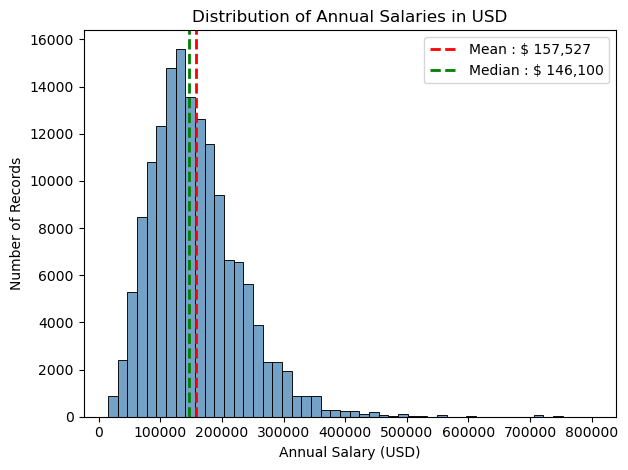

In [5]:
plt.Figure(figsize=(10,6))

sns.histplot(
    data= df_analysis,
    x= "salary_in_usd",
    bins=50,
    color="steelblue"
)

plt.axvline(
    salary_mean,
    color= "red",
    linestyle= "--",
    linewidth=2,
    label=f"Mean : ${salary_mean: ,.0f}"
)

plt.axvline(
    salary_median,
    color="green",
    linestyle= "--",
    linewidth=2,
    label= f"Median : ${salary_median: ,.0f}"
)

plt.title("Distribution of Annual Salaries in USD")
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Number of Records")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.legend()
plt.tight_layout()
plt.show()

### Insight

The salary distribution is right-skewed, with most salary records concentrated around the middle of the distribution and a relatively small number of extremely high salaries.

The mean annual salary is approximately $157,527, while the median is $146,100. The mean is about $11,427 higher than the median because high-salary records pull the average upward.

Therefore, the median is a more appropriate measure for describing a typical salary in this dataset.

### Salary Boxplot

A boxplot is used to summarize the salary distribution and visually identify statistically unusual salaries using the interquartile range.

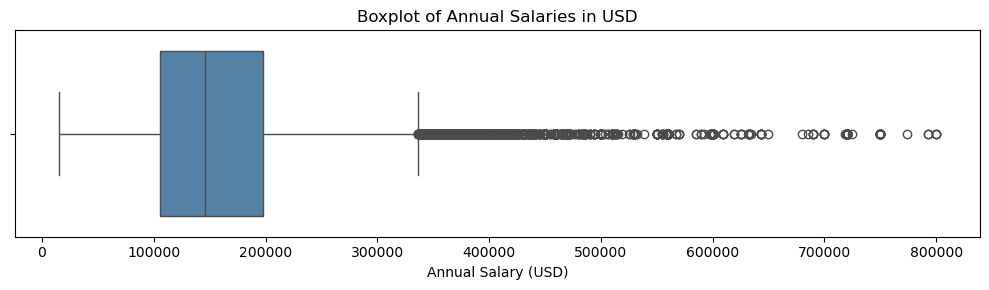

In [6]:
plt.figure(figsize=(10,3))

sns.boxplot(
    data=df_analysis,
    x="salary_in_usd",
    color="steelblue"
)

plt.title("Boxplot of Annual Salaries in USD")
plt.xlabel("Annual Salary (USD)")

plt.ticklabel_format(
    style="plain",
    axis="x"
)

plt.tight_layout()
plt.show()

### Boxplot Insight

The middle 50% of annual salaries lies between approximately $105,800 and $198,000, with a median salary of $146,100.

Salaries above approximately $336,300 are classified as statistical outliers using the IQR rule. These records were retained because they may represent valid high-paying roles rather than data errors.

The long upper tail confirms that the salary distribution is right-skewed.

## 2. Salary by Experience Level

This section examines how salary levels differ across entry-level, mid-level, senior-level, and executive-level roles.

In [7]:
experience_order = [
    "Entry-level",
    "Mid-level",
    "Senior-level",
    "Executive-level"
]

experience_salary_summary = (
    df_analysis.groupby("experience_level_label")
    .agg(
      record_count = ("salary_in_usd", "count"),
      median_salary = ("salary_in_usd", "median"),
      mean_salary = ("salary_in_usd", "mean")
    )
    .reindex(experience_order)
    .round(0)
)

experience_salary_summary

,record_count,median_salary,mean_salary
experience_level_label,,,
Entry-level,13663,86600.0,98962.0
Mid-level,46128,130000.0,142301.0
Senior-level,87491,161000.0,172658.0
Executive-level,4163,189370.0,200471.0


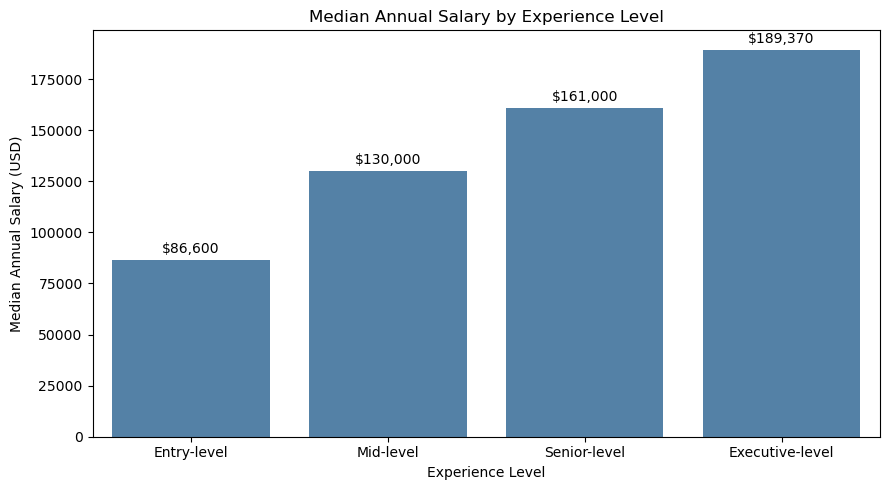

In [8]:
experience_plot_data = (
    experience_salary_summary.reset_index()
)

plt.figure(figsize=(9,5))

ax = sns.barplot(
    data= experience_plot_data,
    x= "experience_level_label",
    y= "median_salary",
    color= "steelblue"
)

plt.title("Median Annual Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Median Annual Salary (USD)")

plt.ticklabel_format(
    style="plain",
    axis="y"
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"${salary:,.0f}"
        for salary in experience_plot_data["median_salary"]
    ],
    padding=3
)

plt.tight_layout()
plt.show()

In [9]:
experience_growth = (
    experience_salary_summary[["median_salary"]].copy()
)

experience_growth["salary_differnce"] = (
    experience_growth["median_salary"].diff()
)

experience_growth["salary_increase_pct"] = (
    experience_growth["median_salary"].pct_change() * 100
)

experience_growth = experience_growth.round(1)

experience_growth

,median_salary,salary_differnce,salary_increase_pct
experience_level_label,,,
Entry-level,86600.0,NaN,NaN
Mid-level,130000.0,43400.0,50.1
Senior-level,161000.0,31000.0,23.8
Executive-level,189370.0,28370.0,17.6


### Experience-Level Salary Insights

Median annual salary increases consistently with experience level, rising from $86,600 for entry-level roles to $189,370 for executive-level roles.

The largest relative salary increase occurs between entry-level and mid-level positions, where the median salary rises by approximately 50.1%.

The median salary continues to increase at higher experience levels, but the relative increase becomes smaller: 23.8% from mid-level to senior-level and 17.6% from senior-level to executive-level.

Mean salaries are higher than median salaries across all experience levels, indicating that high-salary observations create right-skewed distributions within each group.

Senior-level records are the most represented in the dataset. However, record counts describe dataset representation and should not be interpreted as direct evidence of labor-market demand.

## 3. Most Represented Job Titles

This section identifies the job titles with the highest number of salary records in the dataset.

Record frequency represents dataset coverage and should not be interpreted as direct evidence of labor-market demand.

In [10]:
job_title_counts = (
    df_analysis["job_title"].value_counts()
)


top_10_job_title = job_title_counts.head(10)
top_10_job_title

job_title
Data Scientist               18751
Software Engineer            16948
Data Engineer                16352
Data Analyst                 13779
Engineer                     11004
Machine Learning Engineer     8887
Manager                       7811
Analyst                       5396
Research Scientist            3460
Product Manager               2576
Name: count, dtype: int64

In [11]:
total_counted_records = job_title_counts.sum()
total_dataset_records = len(df_analysis)

total_counted_records, total_dataset_records

(np.int64(151445), 151445)

In [12]:
top_10_records = top_10_job_title.sum()

top_10_share_pct = (
    top_10_records / len(df_analysis) * 100
)

top_10_records, round(top_10_share_pct, 1)

(np.int64(104964), np.float64(69.3))

In [13]:
top_10_job_title_df = (
    top_10_job_title.rename_axis("job_title").reset_index(name="record_count")
)

top_10_job_title_df

,job_title,record_count
0,Data Scientist,18751
1,Software Engineer,16948
2,Data Engineer,16352
3,Data Analyst,13779
4,Engineer,11004
5,Machine Learning Engineer,8887
6,Manager,7811
7,Analyst,5396
8,Research Scientist,3460
9,Product Manager,2576


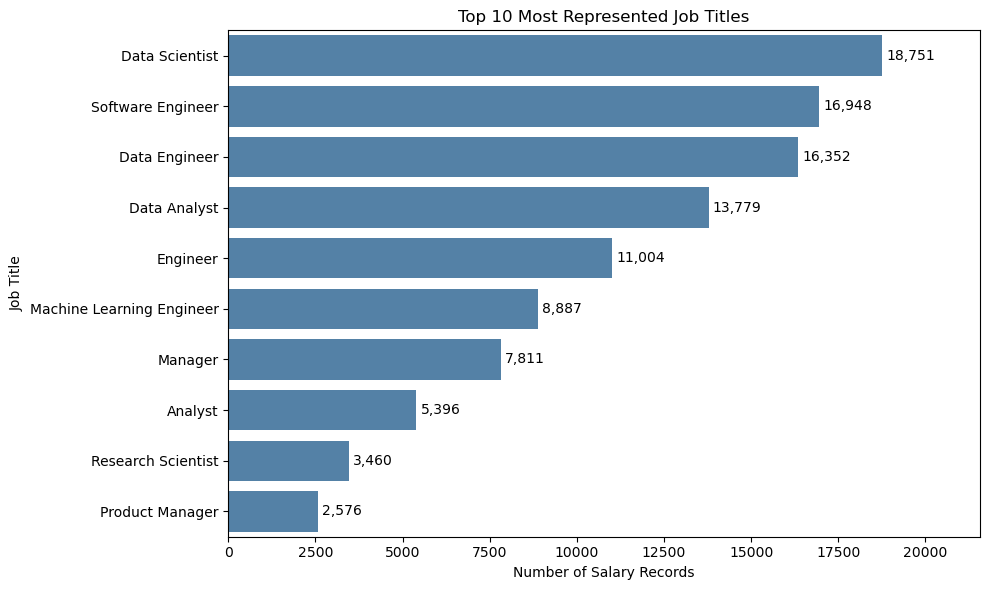

In [14]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_10_job_title_df,
    x= "record_count",
    y= "job_title",
    color="steelblue"
)

plt.title("Top 10 Most Represented Job Titles")
plt.xlabel("Number of Salary Records")
plt.ylabel("Job Title")

count_labels = []

for count in top_10_job_title_df["record_count"]:
    formatted_count = f"{count:,}"
    count_labels.append(formatted_count)

bars = ax.containers[0]

ax.bar_label(
    bars,
    labels=count_labels,
    padding=3
)


maximum_count = top_10_job_title_df["record_count"].max()

plt.xlim(
    0,
    maximum_count * 1.15
)

plt.tight_layout()
plt.show()

### Job Title Representation Insights

Data Scientist is the most represented job title in the dataset, with 18,751 salary records, followed by Software Engineer with 16,948 records and Data Engineer with 16,352 records.

The ten most represented job titles account for approximately 69.3% of all salary records, indicating that the dataset is concentrated around a relatively small group of roles despite containing 422 unique job titles.

Generic titles such as Engineer, Manager, and Analyst may combine different responsibilities and specializations. Therefore, salary comparisons involving these broad titles should be interpreted carefully.

Record frequency represents dataset coverage and should not be interpreted as direct evidence of labor-market demand.

## 4. Highest-Paying Job Titles

This section compares median salaries across job titles while applying a minimum record threshold to reduce unreliable rankings caused by very small sample sizes.

In [17]:
job_title_salary_summary = (
    df_analysis.groupby("job_title").agg(
        record_count=("salary_in_usd", "count"),
        median_salary=("salary_in_usd", "median"),
        mean_salary=("salary_in_usd", "mean")
    )
    .reset_index()
    .round(0)
)

job_title_salary_summary.head(10)

,job_title,record_count,median_salary,mean_salary
0,AI Architect,289,193800.0,210091.0
1,AI Content Writer,3,43680.0,40507.0
2,AI Data Engineer,2,94444.0,94444.0
3,AI Data Scientist,12,63462.0,87254.0
4,AI Developer,222,141400.0,153505.0
5,AI Engineer,2013,165000.0,173515.0
6,AI Engineering Lead,1,23649.0,23649.0
7,AI Engineering Manager,2,179930.0,179930.0
8,AI Governance Lead,4,151120.0,169041.0
9,AI Governance Specialist,8,106088.0,117968.0


In [18]:
job_title_salary_summary["record_count"].describe()

count      422.000000
mean       358.874408
std       1820.468706
min          1.000000
25%          3.000000
50%         14.000000
75%         77.000000
max      18751.000000
Name: record_count, dtype: float64

In [19]:
thresholds = [25, 50, 100, 250, 500]

for threshold in thresholds:
    eligble_title_count = (
        job_title_salary_summary["record_count"] >= threshold
    ).sum()

    print(
        f"At lest {threshold} records : "
        f"{eligble_title_count} job titels"
    )

At lest 25 records : 174 job titels
At lest 50 records : 132 job titels
At lest 100 records : 93 job titels
At lest 250 records : 52 job titels
At lest 500 records : 35 job titels


### Minimum Sample Threshold

A minimum threshold of 100 salary records per job title was selected.

This threshold provides a practical balance between reducing unreliable salary rankings caused by small samples and retaining a sufficiently diverse set of job titles for comparison.

After applying the threshold, 93 out of 422 job titles remain eligible for salary analysis.

In [20]:
minimum_records = 100

eligble_mask = (
    job_title_salary_summary["record_count"] >= minimum_records
)

eligble_job_titles = (
    job_title_salary_summary.loc[eligble_mask].copy()
)

len(eligble_job_titles)

93

In [22]:
top_paying_job_titles = (
    eligble_job_titles.sort_values(
        by="median_salary",
        ascending=False
    )
    .head(10)
    .reset_index(drop=True)
)

top_paying_job_titles

,job_title,record_count,median_salary,mean_salary
0,Engineering Manager,902,240000.0,258211.0
1,Head of Data,336,210000.0,221691.0
2,Director,792,200000.0,211617.0
3,AI Architect,289,193800.0,210091.0
4,Machine Learning Engineer,8887,189000.0,198707.0
5,Research Engineer,1737,185000.0,210903.0
6,Product Designer,205,185000.0,194871.0
7,Technical Lead,248,184960.0,196021.0
8,Solutions Architect,976,184000.0,192277.0
9,Data Infrastructure Engineer,108,183655.0,192640.0


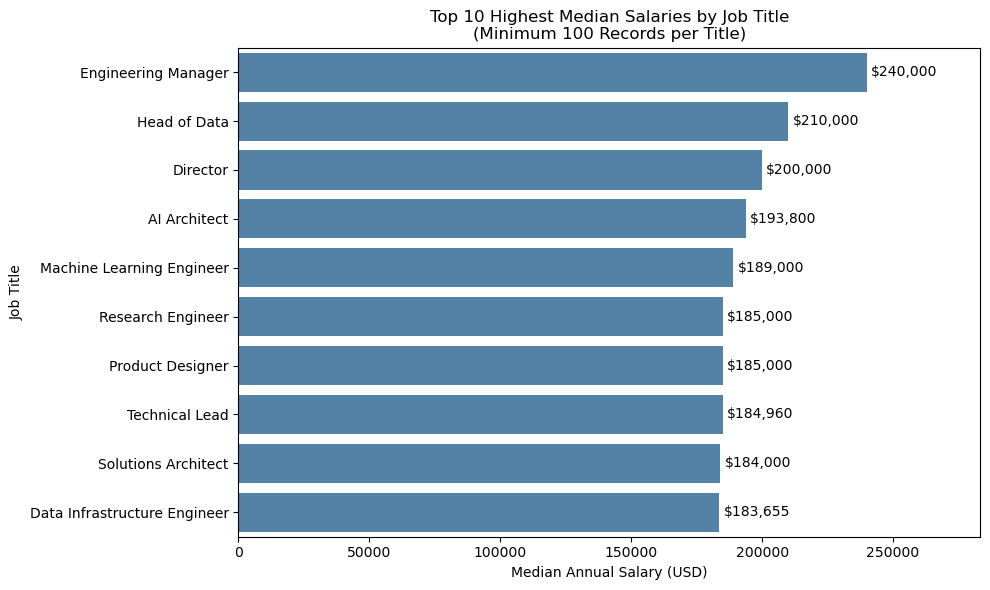

In [24]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=top_paying_job_titles,
    x="median_salary",
    y= "job_title",
    color= "steelblue"
)

plt.title("Top 10 Highest Median Salaries by Job Title\n"
    "(Minimum 100 Records per Title)")
plt.xlabel("Median Annual Salary (USD)")
plt.ylabel("Job Title")

salary_labels= []

for salary in top_paying_job_titles["median_salary"]:
    formatted_salary = f"${salary:,.0f}"
    salary_labels.append(formatted_salary)

bars = ax.containers[0]

ax.bar_label(
    bars,
    labels= salary_labels,
    padding=3
)

maximum_salary = top_paying_job_titles["median_salary"].max()

plt.xlim(
    0,
    maximum_salary * 1.18
)

plt.tight_layout()
plt.show()

### Highest-Paying Job Title Insights

Among job titles with at least 100 salary records, Engineering Manager has the highest median annual salary at $240,000, followed by Head of Data at $210,000 and Director at $200,000.

Leadership, engineering, and architecture-oriented roles appear frequently among the highest-median-salary job titles.

Machine Learning Engineer has a median salary of $189,000 based on 8,887 records, making it one of the most strongly represented titles in the ranking. In contrast, some other titles are based on samples closer to the minimum threshold and should be interpreted with greater caution.

The results describe associations within this dataset and do not establish that job title alone causes salary differences. Salary may also be influenced by experience level, country, year, company size, and work arrangement.

Only job titles with at least 100 records were included to reduce the influence of very small samples.